# Домашнє завдання. Тема 1: Спектральна кластеризація на наборі даних Iris

**Мета:** Завантажити дані Iris, виконати спектральну кластеризацію та оцінити результати за допомогою Confusion Matrix.

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 1. Завантажити та створити DataFrame

In [44]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Розмір датасету: {df.shape}")
df.head(10)

Розмір датасету: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


## 2. Базові статистичні характеристики

In [45]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [46]:
print("Кількість спостережень за класами:")
print(df['species'].value_counts())
print(f"\nПропущені значення: {df.isnull().sum().sum()}")

Кількість спостережень за класами:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Пропущені значення: 0


## 3. Візуалізація розподілу спостережень за класами

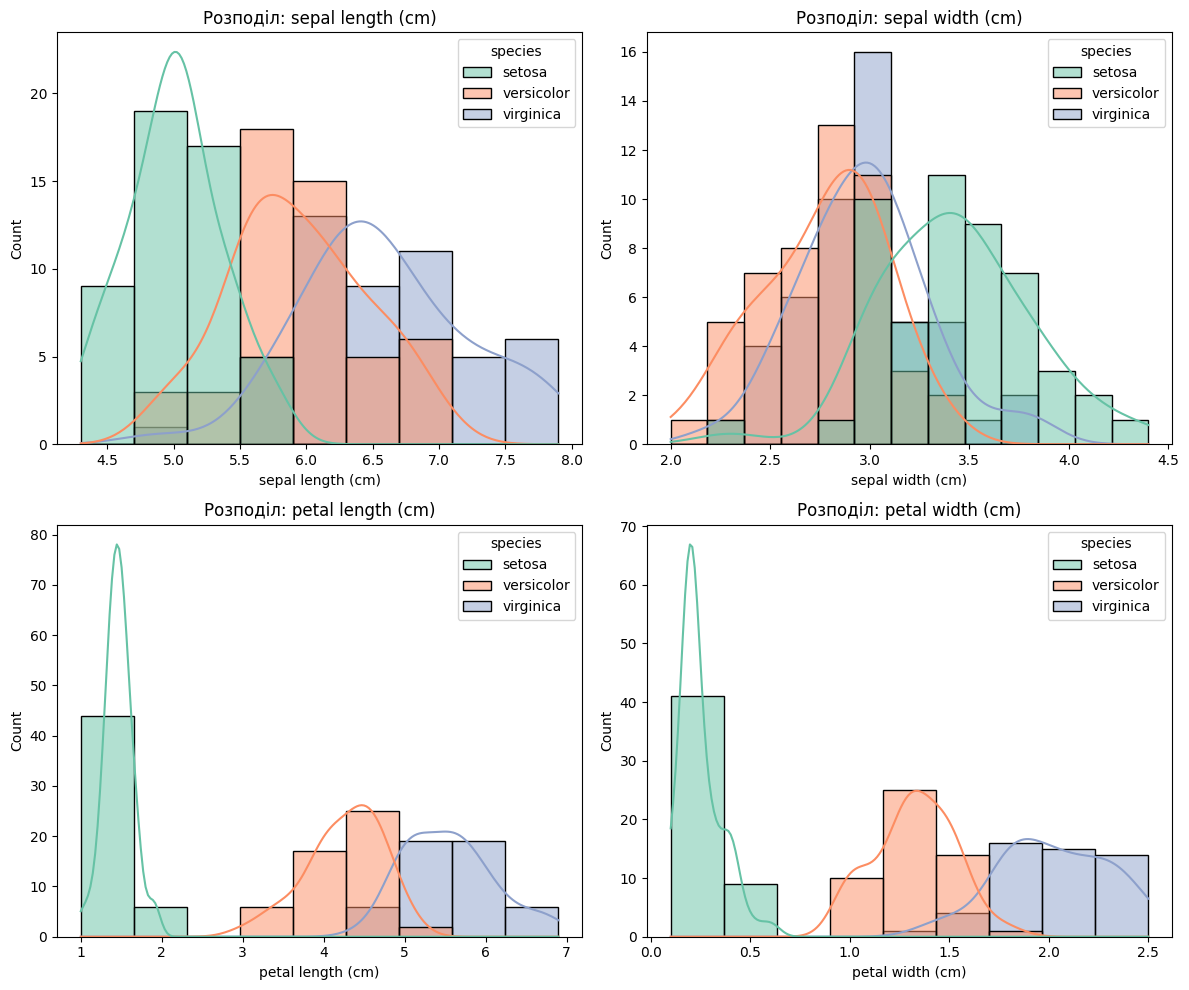

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(iris.feature_names):
    ax = axes[i // 2][i % 2]
    sns.histplot(data=df, x=col, hue='species', kde=True, ax=ax, palette='Set2')
    ax.set_title(f'Розподіл: {col}')

plt.tight_layout()
plt.show()

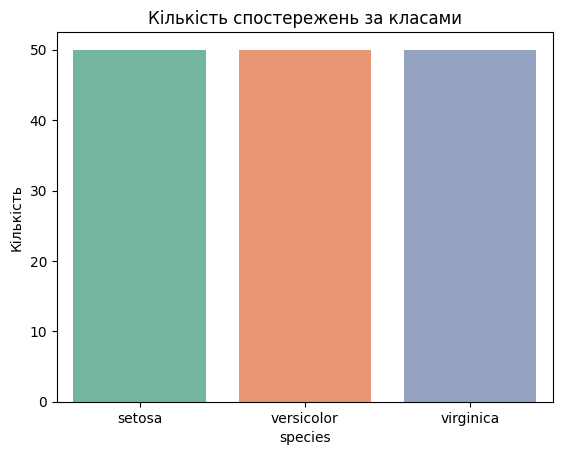

In [48]:
sns.countplot(data=df, x='species', hue='species', palette='Set2', legend=False)
plt.title('Кількість спостережень за класами')
plt.ylabel('Кількість')
plt.show()

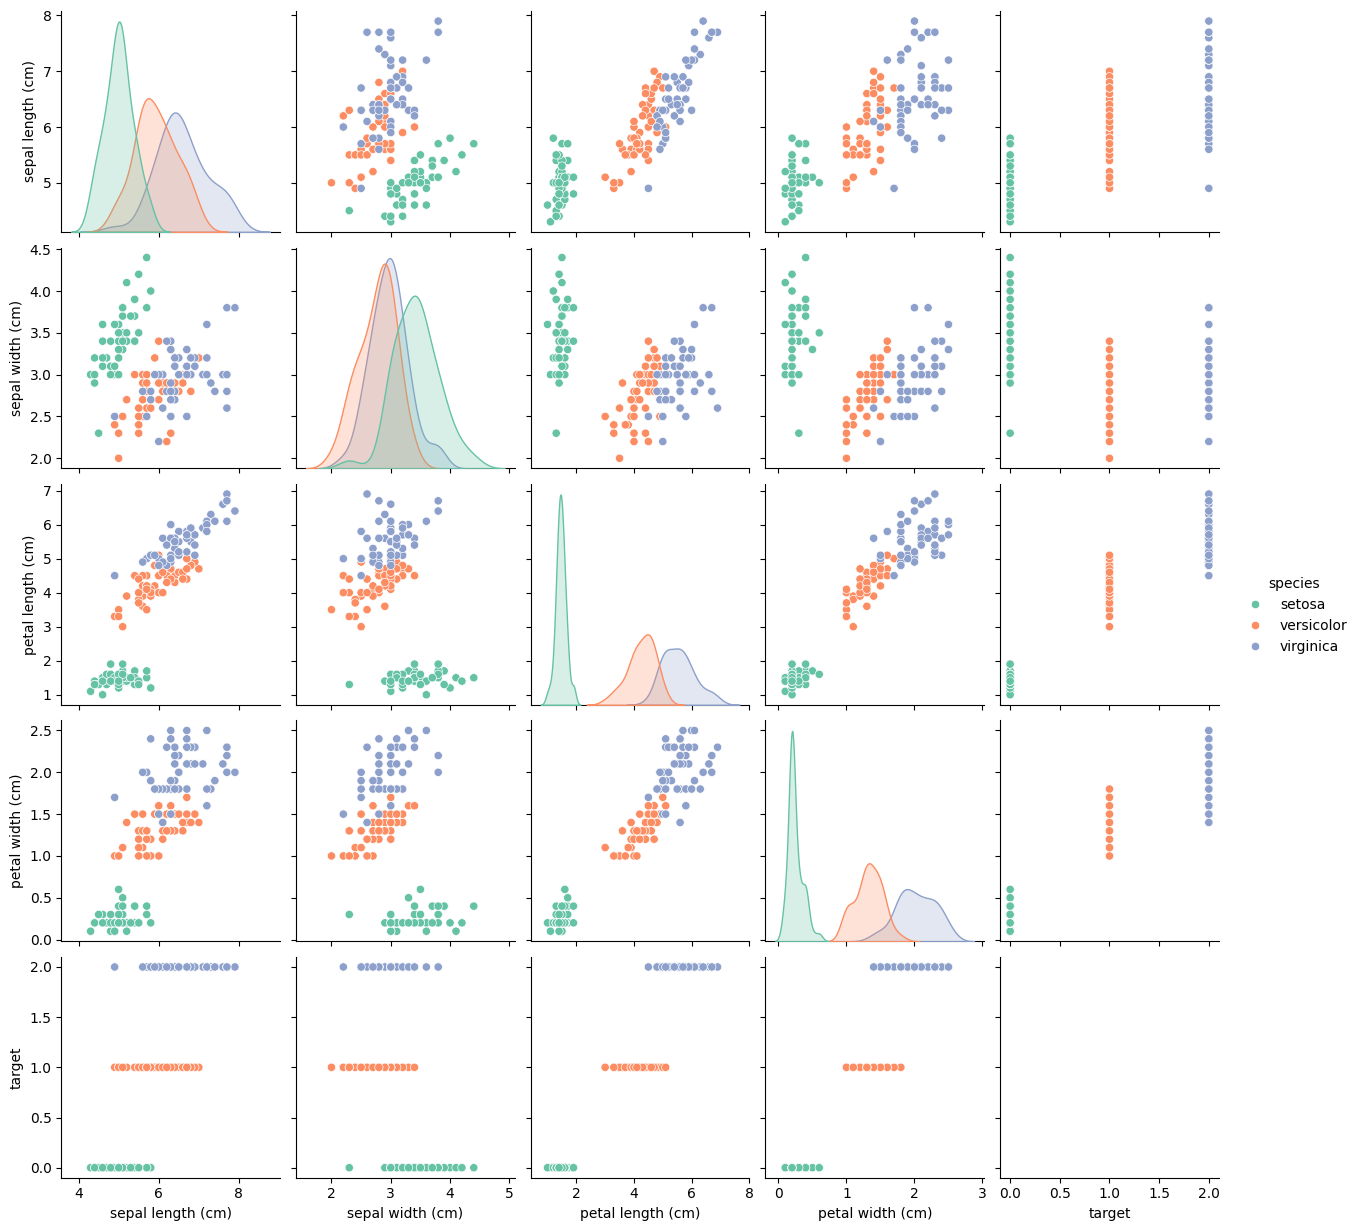

In [49]:
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')
plt.show()

## 4. Стандартизація даних

In [50]:
X = df[iris.feature_names].values
y_true = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)
print("Статистики після стандартизації:")
df_scaled.describe().round(2)

Статистики після стандартизації:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71


## 5. Спектральна кластеризація

In [51]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity='rbf',
    gamma=1.0,
    random_state=42,
    assign_labels='kmeans'
)

y_pred = spectral.fit_predict(X_scaled)

print("Розподіл за кластерами:")
print(pd.Series(y_pred).value_counts().sort_index())

Розподіл за кластерами:
0    63
1    50
2    37
Name: count, dtype: int64


## 6. Порівняння кластерів із дійсними класами (Confusion Matrix)

Мітки кластерів не обов'язково збігаються з мітками класів. Знаходимо найкраще відповідність між кластерами та класами.

Confusion Matrix:
[[ 0 50  0]
 [45  0  5]
 [18  0 32]]


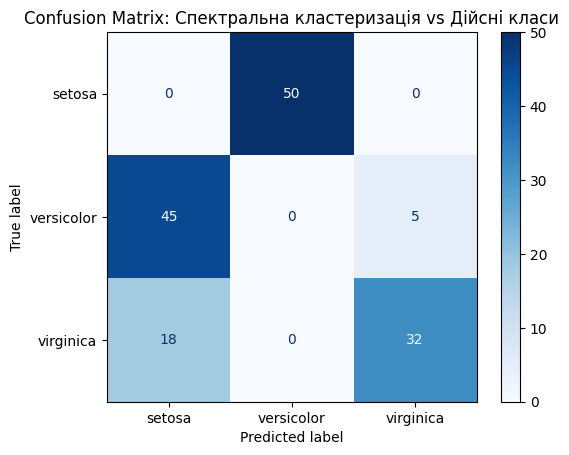

In [52]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Спектральна кластеризація vs Дійсні класи')
plt.show()

## 7. Візуалізація результатів кластеризації

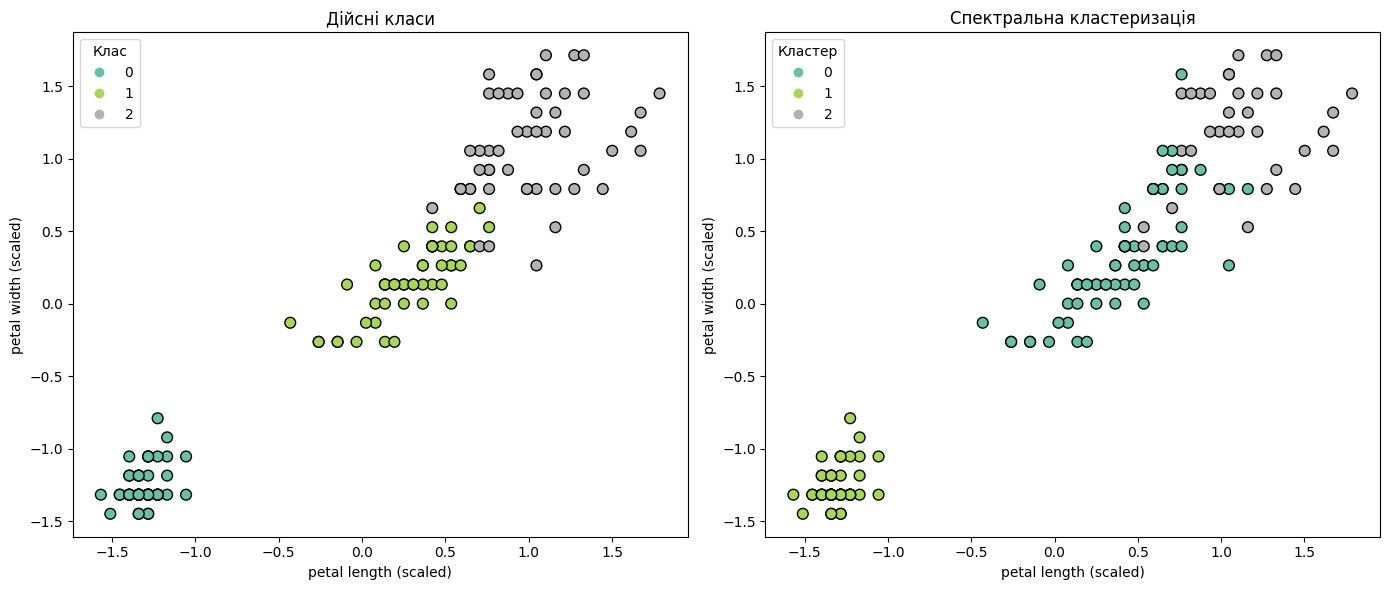

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_scaled[:, 2], X_scaled[:, 3],
    c=y_true, cmap='Set2', edgecolors='k', s=60
)
axes[0].set_xlabel('petal length (scaled)')
axes[0].set_ylabel('petal width (scaled)')
axes[0].set_title('Дійсні класи')
axes[0].legend(*scatter1.legend_elements(), title='Клас')

scatter2 = axes[1].scatter(
    X_scaled[:, 2], X_scaled[:, 3],
    c=y_pred, cmap='Set2', edgecolors='k', s=60
)
axes[1].set_xlabel('petal length (scaled)')
axes[1].set_ylabel('petal width (scaled)')
axes[1].set_title('Спектральна кластеризація')
axes[1].legend(*scatter2.legend_elements(), title='Кластер')

plt.tight_layout()
plt.show()

## 8. Висновок

**Результати спектральної кластеризації на Iris:**

1. **Завантаження та аналіз даних.** Набір даних Iris містить 150 спостережень із 4 ознаками для 3 класів (по 50 у кожному). Ознаки petal length та petal width мають найбільшу розділювальну здатність між класами.

2. **Стандартизація.** Дані були стандартизовані (середнє ≈ 0, стандартне відхилення ≈ 1) для коректної роботи алгоритму, оскільки спектральна кластеризація чутлива до масштабу ознак.

3. **Спектральна кластеризація.** Алгоритм з параметром `affinity='rbf'` та `gamma=1.0` показав високу якість поділу на кластери. Клас setosa виділяється ідеально (він лінійно відокремлений).

4. **Confusion Matrix.** Матриця плутанини підтвердила, що спектральна кластеризація добре відтворює структуру дійсних класів. Основні помилки зосереджені між versicolor та virginica.

Спектральна кластеризація є потужним методом, який добре працює з нелінійно розділеними даними, використовуючи граф подібності та його спектральні властивості для знаходження кластерів.